In [1]:
import math
import numpy as np
import pandas as pd
np.random.seed(123)

import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.cluster import KMeans

import seaborn as sns

In [3]:
data = pd.read_csv('Data.csv')

In [5]:
data

,x,y
0,-0.542,23.761
1,8.129,25.661
2,4.239,25.298
3,-0.691,25.230
4,3.539,21.645
5,2.122,35.833
6,-1.398,37.559
7,6.127,38.198
8,3.119,36.675
9,0.741,25.409


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       60 non-null     float64
 1   y       60 non-null     float64
dtypes: float64(2)
memory usage: 1.1 KB


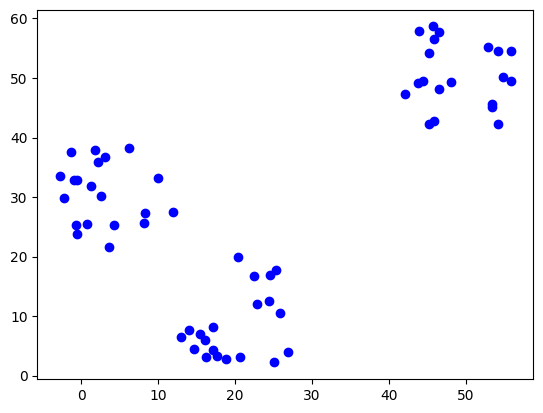

In [9]:
plt.scatter(data['x'], data['y'], c='b')
plt.show()

In [13]:
# data.min().min()

-2.808

In [15]:
data.shape[1]

2

In [17]:
# init centr

def initialize_cent(k, data):
    n = data.shape[1]
    cent_min = data.min().min()
    cent_max = data.max().max()
    centroids=[]
    for cent in range(k):
        cent = np.random.uniform(cent_min, cent_max, n)
        centroids.append(cent)
    centroids = pd.DataFrame(centroids, columns=data.columns)
    return centroids

In [21]:
centroids = initialize_cent(k=3, data=data)
centroids

,x,y
0,39.996300,14.777837
1,11.134063,31.075254
2,41.409843,23.195700


In [23]:
# error
def calculate_error(a, b):
    error = np.square(np.sum((a-b)**2))
    return error

In [25]:
errors = np.array([])
for cent in range(centroids.shape[0]):
    error = calculate_error(centroids.iloc[cent, :], data.iloc[0, :])
    errors = np.append(errors, error)

In [27]:
errors

array([2972351.68265223,   36034.96413044, 3098574.16619018])

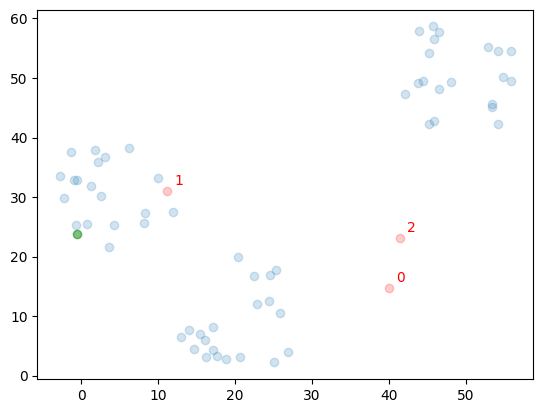

In [29]:
plt.scatter(data.iloc[1:, 0], data.iloc[1:, 1], marker= 'o', alpha=0.2)

plt.scatter(centroids.iloc[:, 0], centroids.iloc[:, 1], marker= 'o', alpha=0.2, c= 'r')

plt.scatter(data.iloc[0,0], data.iloc[0,1], marker= 'o', alpha=0.5, c='g')


for i in range(centroids.shape[0]):
    plt.text(centroids.iloc[i,0]+1, centroids.iloc[i,1]+1, s=centroids.index[i], c='r')

In [45]:
# assign
np.where(errors == np.min(errors))[0].tolist()[0]

1

In [47]:
def assign_centroid(data, centroids):
    m = data.shape[0]
    centroid_assign = []
    centroid_errors = []
    k = centroids.shape[0]
    for x in range(m):
        errors = np.array([])
        for centroid in range(k):
            error = calculate_error(centroids.iloc[centroid, :2], data.iloc[x, :2])
            errors = np.append(errors, error)
        close_cent = np.where(errors == np.min(errors))[0].tolist()[0]
        centroid_error = np.min(errors)
        centroid_assign.append(close_cent)
        centroid_errors.append(centroid_error)
    return (centroid_assign, centroid_errors)

In [49]:
data['centroid'], data['error'] = assign_centroid(data, centroids)

In [55]:
# data

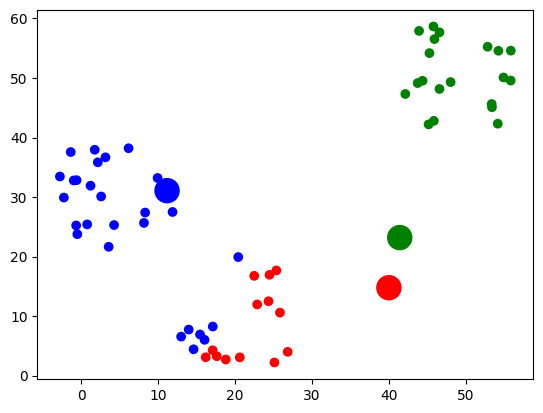

In [57]:
colors = {0:'red', 1:'blue', 2:'green'}

plt.scatter(data.iloc[:,0], data.iloc[:,1],
            marker='o', c= data['centroid'].apply(lambda x: colors[x]))
plt.scatter(centroids.iloc[:,0], centroids.iloc[:,1], marker='o', s=300, c = centroids.index.map(lambda x: colors[x]))